In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
 

In [2]:
train_df = pd.read_csv("datasets/FPB_train.csv")
test_df  = pd.read_csv("datasets/FPB_test.csv")
 


In [3]:
text_col  = train_df.columns[1]
label_col = train_df.columns[0]

X_train = train_df[text_col].astype(str)
y_train = train_df[label_col]
X_test  = test_df[text_col].astype(str)
y_test  = test_df[label_col]


In [4]:
n_values = range(1, 8)
accuracy_matrix = np.full((8, 8), np.nan)
runtime_matrix  = np.full((8, 8), np.nan)

for start in n_values:
    for end in range(start, 8):
        vectorizer = CountVectorizer(ngram_range=(start, end))
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec  = vectorizer.transform(X_test)

        clf = MultinomialNB(alpha=1)

        t0 = time.time()
        clf.fit(X_train_vec, y_train)
        y_pred = clf.predict(X_test_vec)
        runtime = time.time() - t0

        acc = accuracy_score(y_test, y_pred)

        accuracy_matrix[start][end] = acc
        runtime_matrix[start][end]  = runtime

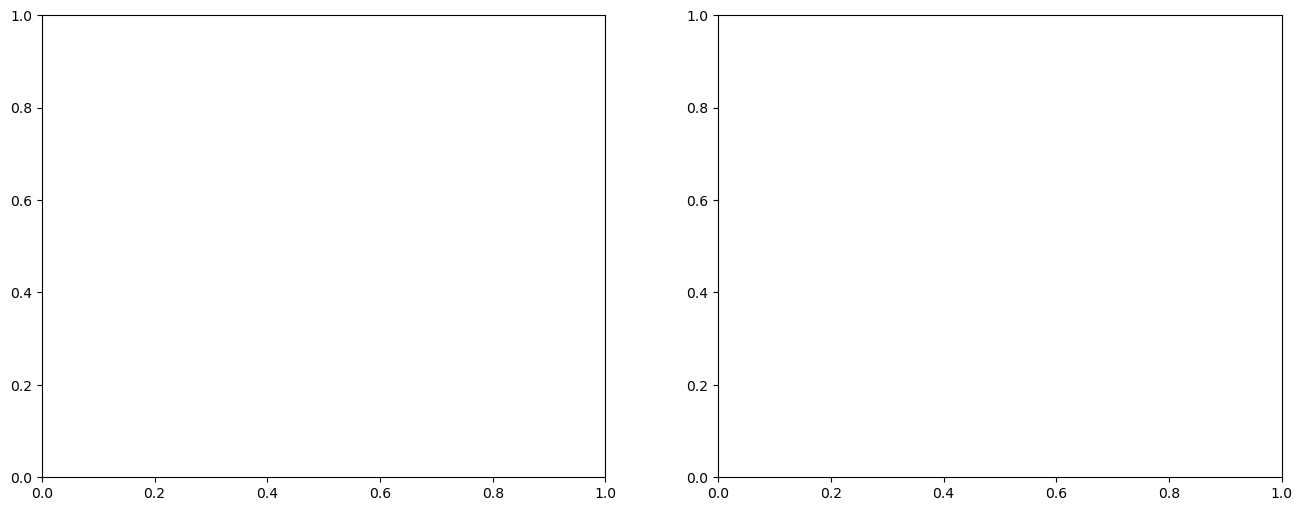

In [5]:
labels = [str(i) for i in range(1, 8)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

In [6]:
sns.heatmap(
    accuracy_matrix[1:, 1:],
    ax=axes[0],
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="YlGnBu",
    mask=np.isnan(accuracy_matrix[1:, 1:])
)
axes[0].set_title("Classification Accuracy by N-gram Range", fontsize=13)
axes[0].set_xlabel("N-gram End")
axes[0].set_ylabel("N-gram Start")


Text(170.72222222222223, 0.5, 'N-gram Start')

sns.heatmap(
    runtime_matrix[1:, 1:],
    ax=axes[1],
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="OrRd",
    mask=np.isnan(runtime_matrix[1:, 1:])
)
axes[1].set_title("Runtime (seconds) by N-gram Range", fontsize=13)
axes[1].set_xlabel("N-gram End")
axes[1].set_ylabel("N-gram Start")

plt.tight_layout()
plt.savefig("ngram_heatmaps.png", dpi=150)
plt.show()

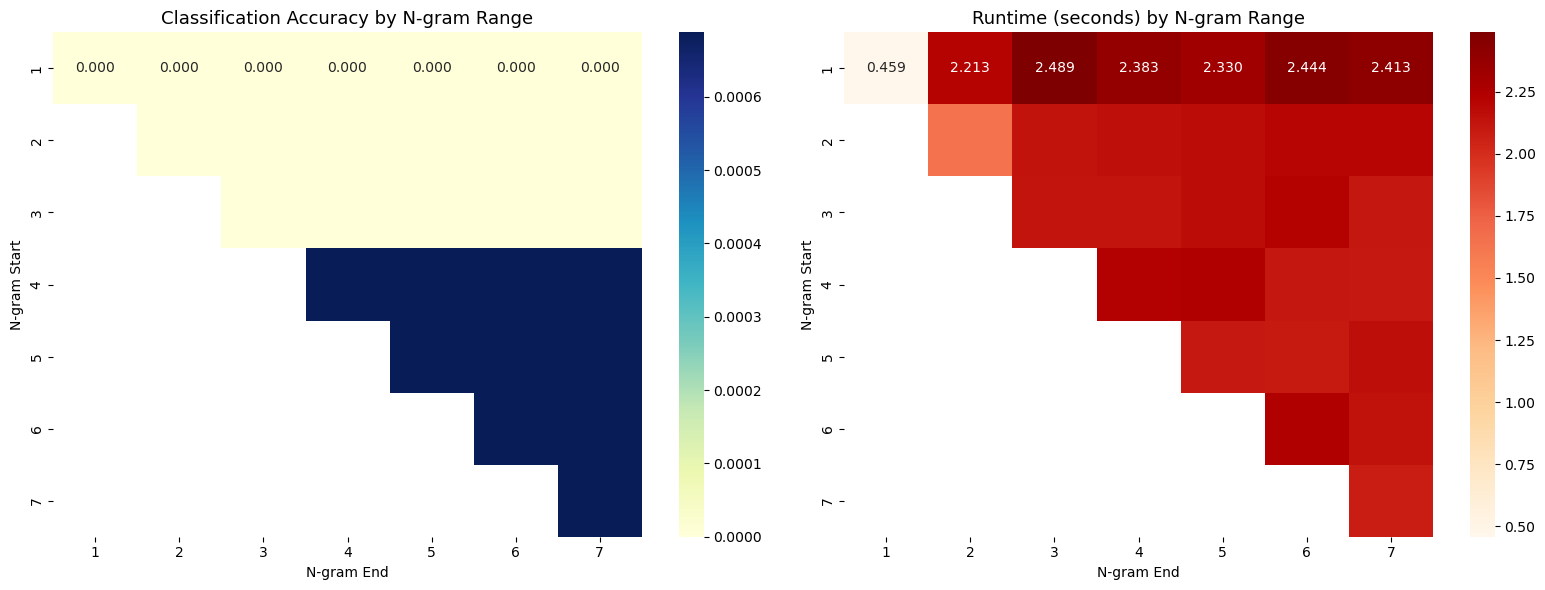

In [7]:
X_train = train_df[text_col].astype(str)
y_train = train_df[label_col]
X_test  = test_df[text_col].astype(str)
y_test  = test_df[label_col]

n_values = range(1, 8)
accuracy_matrix = np.full((8, 8), np.nan)
runtime_matrix  = np.full((8, 8), np.nan)

for start in n_values:
    for end in range(start, 8):
        vectorizer = CountVectorizer(ngram_range=(start, end), max_features=50000)
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec  = vectorizer.transform(X_test)

        clf = MultinomialNB(alpha=1)

        t0 = time.time()
        clf.fit(X_train_vec, y_train)
        y_pred = clf.predict(X_test_vec)
        runtime = time.time() - t0

        acc = accuracy_score(y_test, y_pred)

        accuracy_matrix[start][end] = acc
        runtime_matrix[start][end]  = runtime

labels = [str(i) for i in range(1, 8)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    accuracy_matrix[1:, 1:],
    ax=axes[0],
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="YlGnBu",
    mask=np.isnan(accuracy_matrix[1:, 1:])
)
axes[0].set_title("Classification Accuracy by N-gram Range", fontsize=13)
axes[0].set_xlabel("N-gram End")
axes[0].set_ylabel("N-gram Start")

sns.heatmap(
    runtime_matrix[1:, 1:],
    ax=axes[1],
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="OrRd",
    mask=np.isnan(runtime_matrix[1:, 1:])
)
axes[1].set_title("Runtime (seconds) by N-gram Range", fontsize=13)
axes[1].set_xlabel("N-gram End")
axes[1].set_ylabel("N-gram Start")

plt.tight_layout()
plt.savefig("ngram_heatmaps.png", dpi=150)
plt.show()
